---
---
# MBA - 2026
## Dirección Financiera

### Profesor Fernando Díaz H.
---

# 📉 Frontera Eficiente y el Efecto de la Diversificación

En este notebook construiremos y analizaremos portafolios de inversión compuestos por varias acciones, con dos objetivos centrales:

* **Ilustrar el efecto de la diversificación:** mostrar cómo la combinación de activos cuyos retornos no están perfectamente correlacionados puede reducir el riesgo total de una cartera sin disminuir necesariamente su retorno esperado.
* **Construir la Frontera Eficiente:** identificar el conjunto de portafolios que ofrecen el mayor retorno esperado para cada nivel de riesgo o, de manera equivalente, el menor riesgo posible para cada nivel de retorno esperado.

Para lograrlo:

1. Descargaremos precios históricos de cinco acciones —AAPL, WMT, INTC, XOM y LMT— y calcularemos sus retornos logarítmicos diarios.
2. Estimaremos el vector de retornos medios y la matriz de varianzas-covarianzas de estos activos.
3. Simularemos, mediante el método de **[Monte Carlo](https://www.ibm.com/es-es/think/topics/monte-carlo-simulation)**, miles de portafolios con ponderaciones aleatorias, calculando para cada uno su retorno esperado, volatilidad y ratio de Sharpe.
4. Identificaremos dos portafolios de referencia:

   * el portafolio de **mínima varianza global**, es decir, el de menor riesgo entre todos los portafolios factibles;
   * el portafolio de **tangencia**, es decir, el que presenta el mayor ratio de Sharpe respecto de la tasa libre de riesgo utilizada.
5. Representaremos los portafolios simulados en el plano riesgo-retorno, trazaremos la Frontera Eficiente y destacaremos ambos portafolios de referencia.

> 💡 **Idea central:** el riesgo de un portafolio no es simplemente el promedio ponderado del riesgo de sus activos individuales. También depende de las covarianzas entre sus retornos, es decir, de la forma en que los activos se mueven conjuntamente. Por esta razón, una combinación adecuada de activos puede reducir significativamente el riesgo total de la cartera y, en algunos casos, situarlo por debajo del riesgo de cualquiera de sus componentes individuales.

<a href="https://www.ibm.com/es-es/think/topics/monte-carlo-simulation" target="_blank">
  <img src="https://commons.wikimedia.org/wiki/Special:Redirect/file/IBM_logo.svg" alt="IBM: simulación de Monte Carlo" width="110">
</a>

*Haz clic en el logotipo para acceder a la explicación de IBM sobre la simulación de Monte Carlo.*


## 📦 Cargando las librerías

Antes de comenzar el análisis, cargaremos los paquetes de **R** que utilizaremos a lo largo del notebook:

* **`tidyquant`**: descarga y manipulación de datos financieros.
* **`timetk`**: transformación y organización de series temporales.
* **`tidyr`**: reorganización de datos entre formatos ancho y largo.
* **`ggplot2`**: construcción de gráficos.
* **`forcats`**: manejo y reordenamiento de variables categóricas.
* **`dplyr`**: transformación, filtrado y organización de bases de datos.

También ajustaremos el tamaño y la resolución de los gráficos para mejorar su visualización dentro del notebook.

> 💡 Las librerías deben instalarse una sola vez, pero deben cargarse cada vez que se inicia una nueva sesión de R.


In [1]:
#install.packages("tidyquant")

In [1]:
suppressWarnings(suppressPackageStartupMessages({
  library(tidyquant) # To download the data
  library(timetk) # To manipulate the data series
  library(tidyr)
  library(ggplot2)
  library(forcats)
  library(dplyr)
}))

# Bigger, higher-resolution plots when rendered to the web page
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 150)

## 📥 Extracción de datos bursátiles

A continuación, descargaremos información histórica de precios para las siguientes acciones:

* **Apple Inc. (`AAPL`)**: empresa tecnológica.
* **Walmart Inc. (`WMT`)**: empresa del sector comercio minorista.
* **Intel Corporation (`INTC`)**: empresa de semiconductores.
* **Exxon Mobil Corporation (`XOM`)**: empresa del sector energético.
* **Lockheed Martin Corporation (`LMT`)**: empresa de los sectores aeroespacial y defensa.

Estas acciones pertenecen a industrias diferentes, lo que permitirá ilustrar cómo la diversificación entre sectores puede contribuir a reducir el riesgo total de un portafolio.

> 💡 Utilizaremos los precios ajustados, ya que incorporan el efecto de dividendos y divisiones de acciones, y permiten calcular retornos históricos de manera más consistente.



### 🏷️ Definiendo los *tickers* de las acciones

Primero, crearemos un objeto llamado `tick` que contendrá los símbolos bursátiles de las cinco acciones seleccionadas:

```r
tick <- c("AAPL", "WMT", "INTC", "XOM", "LMT")
```

En **R**, la función `c()` permite combinar varios elementos dentro de un mismo vector.

Cada elemento del objeto `tick` corresponde al símbolo utilizado por Yahoo Finance para identificar una acción:

* `AAPL`: Apple Inc.
* `WMT`: Walmart Inc.
* `INTC`: Intel Corporation.
* `XOM`: Exxon Mobil Corporation.
* `LMT`: Lockheed Martin Corporation.

Este vector será utilizado posteriormente en `tq_get()` para descargar simultáneamente los precios históricos de las cinco acciones.

> 💡 El nombre del objeto puede ser cualquiera, pero utilizaremos `tick` como una abreviación de *tickers*.


In [2]:

tick <- c('AAPL', 'WMT', 'INTC', 'XOM', 'LMT')
tick

[1] "AAPL" "WMT"  "INTC" "XOM"  "LMT"

In [3]:
tick
length(tick)

[1] "AAPL" "WMT"  "INTC" "XOM"  "LMT"

[1] 5

### 📥 Descarga de precios históricos

Como vimos en la clase anterior, **Riesgo y Retorno**, el paquete `tidyquant` permite trabajar con datos financieros dentro de la estructura y sintaxis del `tidyverse`.

En particular, la función `tq_get()` se utiliza para descargar información financiera directamente desde fuentes como Yahoo Finance y almacenarla en un objeto de **R**.

A continuación, descargaremos los precios históricos de las cinco acciones seleccionadas para el período de **cinco años que finalizó ayer**. Los datos obtenidos serán almacenados en el objeto `price_data`.

Para ello, utilizaremos:

* `tick`: vector que contiene los símbolos bursátiles de las acciones;
* `from`: fecha de inicio del período;
* `to`: fecha final del período;
* `get = "stock.prices"`: indica que queremos descargar precios bursátiles históricos.

> 💡 Vamos a descargar 5 años de datos.


In [4]:
price_data <- tq_get(tick,
                     from = '2021-01-01',
                     to = '2025-12-31',
                     get = 'stock.prices')
print(price_data)

# A tibble: 6,270 × 8
   symbol date        open  high   low close    volume adjusted
   <chr>  <date>     <dbl> <dbl> <dbl> <dbl>     <dbl>    <dbl>
 1 AAPL   2021-01-04  134.  134.  127.  129. 143301900     126.
 2 AAPL   2021-01-05  129.  132.  128.  131.  97664900     127.
 3 AAPL   2021-01-06  128.  131.  126.  127. 155088000     123.
 4 AAPL   2021-01-07  128.  132.  128.  131. 109578200     127.
 5 AAPL   2021-01-08  132.  133.  130.  132. 105158200     128.
 6 AAPL   2021-01-11  129.  130.  128.  129. 100384500     125.
 7 AAPL   2021-01-12  128.  130.  127.  129.  91951100     125.
 8 AAPL   2021-01-13  129.  131.  128.  131.  88636800     127.
 9 AAPL   2021-01-14  131.  131   129.  129.  90221800     125.
10 AAPL   2021-01-15  129.  130.  127   127. 111598500     124.
# ℹ 6,260 more rows


In [5]:
cat("Clase del objeto:", class(price_data), "\n")

suppressPackageStartupMessages(library(knitr))
suppressPackageStartupMessages(library(IRdisplay))

display_html(as.character(
  kable(head(price_data, 10), format = "html", digits = 2, format.args = list(big.mark = ","))
))

cat(sprintf(
  "price_data contiene %s observaciones (%d activos x %d días de trading, aprox.).",
  format(nrow(price_data), big.mark = ","),
  length(unique(price_data$symbol)),
  nrow(price_data) %/% length(unique(price_data$symbol))
))

Clase del objeto: tbl_df tbl data.frame 


symbol,date,open,high,low,close,volume,adjusted
AAPL,2021-01-04,133.52,133.61,126.76,129.41,"143,301,900",125.74
AAPL,2021-01-05,128.89,131.74,128.43,131.01,"97,664,900",127.30
AAPL,2021-01-06,127.72,131.05,126.38,126.60,"155,088,000",123.01
AAPL,2021-01-07,128.36,131.63,127.86,130.92,"109,578,200",127.21
AAPL,2021-01-08,132.43,132.63,130.23,132.05,"105,158,200",128.31
AAPL,2021-01-11,129.19,130.17,128.50,128.98,"100,384,500",125.32
AAPL,2021-01-12,128.50,129.69,126.86,128.80,"91,951,100",125.15
AAPL,2021-01-13,128.76,131.45,128.49,130.89,"88,636,800",127.18
AAPL,2021-01-14,130.80,131.00,128.76,128.91,"90,221,800",125.26
AAPL,2021-01-15,128.78,130.22,127.00,127.14,"111,598,500",123.54


price_data contiene 6,270 observaciones (5 activos x 1254 días de trading, aprox.).

## 📈 Retornos diarios

A continuación, calcularemos los retornos diarios de las cinco acciones a partir de sus precios ajustados.

Utilizaremos **retornos logarítmicos**, definidos como:

$$r_{i,t}=\ln\left(\frac{P_{i,t}}{P_{i,t-1}}\right)$$

donde:

* $P_{i,t}$ es el precio ajustado de la acción $i$ en el día $t$;
* $P_{i,t-1}$ es su precio ajustado en el día bursátil anterior;
* $r_{i,t}$ es el retorno logarítmico diario.

Los retornos logarítmicos son especialmente útiles porque pueden sumarse a través del tiempo. Por ejemplo, el retorno logarítmico acumulado durante varios días corresponde a la suma de los retornos diarios del período.

La información obtenida será almacenada en el objeto `log_red_tidy`, manteniendo los datos en formato largo o *tidy*: una observación por fecha y por acción.

> 💡 El primer retorno de cada acción será `NA`, porque no existe un precio anterior dentro de la muestra con el cual calcular su variación.



In [6]:
log_ret_tidy <- price_data |>
  group_by(symbol) |>
  tq_transmute(select = adjusted,
               mutate_fun = periodReturn,
               period = 'daily',
               col_rename = 'ret',
               type = 'log')

In [7]:
head(log_ret_tidy)
tail(log_ret_tidy)

symbol,date,ret
<chr>,<date>,<dbl>
AAPL,2021-01-04,0.000000000
AAPL,2021-01-05,0.012287687
AAPL,2021-01-06,-0.034240921
AAPL,2021-01-07,0.033553956
AAPL,2021-01-08,0.008594191
AAPL,2021-01-11,-0.023523280


symbol,date,ret
<chr>,<date>,<dbl>
LMT,2025-12-22,0.019714541
LMT,2025-12-23,-0.002111611
LMT,2025-12-24,0.006609580
LMT,2025-12-26,-0.005615322
LMT,2025-12-29,0.012017856
LMT,2025-12-30,-0.001781183


El operador `|>` (**pipe operator** nativo de R, disponible desde la versión 4.1) permite encadenar secuencialmente varias operaciones en un flujo de trabajo de análisis de datos. Esto hace que el código sea más legible, ya que las operaciones se ejecutan de izquierda a derecha, pasando el resultado de la operación anterior como el primer argumento de la siguiente operación.

La función **group_by()** se usa para agrupar los datos en un marco de datos según una o varias variables.

 La función **tq_transmute** se utiliza para transformar y resumir datos financieros



In [8]:
head(log_ret_tidy)

symbol,date,ret
<chr>,<date>,<dbl>
AAPL,2021-01-04,0.000000000
AAPL,2021-01-05,0.012287687
AAPL,2021-01-06,-0.034240921
AAPL,2021-01-07,0.033553956
AAPL,2021-01-08,0.008594191
AAPL,2021-01-11,-0.023523280


## 🔄 Formato "Ancho"

La función **pivot_wider** es parte del paquete **tidyr** en R y se utiliza para transformar datos de formato largo a formato ancho, creando nuevas columnas basadas en valores únicos en una columna y llenando esas columnas con valores de otra columna.

In [9]:
log_ret_xts <- log_ret_tidy |>
  pivot_wider(names_from = symbol, values_from =ret) |>
  tk_xts(date_var = date, silent = TRUE)

head(log_ret_xts)

                   AAPL           WMT         INTC         XOM          LMT
2021-01-04  0.000000000  0.000000e+00  0.000000000 0.000000000  0.000000000
2021-01-05  0.012287687 -5.337504e-03  0.018747742 0.047067745  0.011969760
2021-01-06 -0.034240921  6.224017e-03  0.009635432 0.025197067 -0.002181274
2021-01-07  0.033553956 -6.825574e-05  0.021106372 0.007815176 -0.015870963
2021-01-08  0.008594191 -1.360223e-04 -0.010400645 0.011059745 -0.019009087
2021-01-11 -0.023523280  4.490933e-03 -0.002132045 0.029904589  0.004689871

Ahora sí tenemos los datos como los necesitamos.

# 📊 II. Estadísticos Requeridos

## 📈 Rentabilidad media diaria de cada activo.

In [10]:
mean_ret <- colMeans(log_ret_xts)
print(round(mean_ret, 5))

    AAPL      WMT     INTC      XOM      LMT 
 0.00062  0.00072 -0.00015  0.00101  0.00039 


## 🧮 Varianzas y Covarianzas

Calcularemos la matriz de covarianzas de todas estas acciones y las anualizaremos multiplicándola por 252.

In [11]:
cov_mat <- cov(log_ret_xts)*252

print(round(cov_mat,4))

       AAPL    WMT   INTC    XOM    LMT
AAPL 0.0771 0.0166 0.0483 0.0143 0.0065
WMT  0.0166 0.0439 0.0118 0.0071 0.0075
INTC 0.0483 0.0118 0.2148 0.0222 0.0059
XOM  0.0143 0.0071 0.0222 0.0731 0.0153
LMT  0.0065 0.0075 0.0059 0.0153 0.0485


# 💼 III. Single Portfolio

Para calcular la rentabilidad de la cartera y el riesgo (desviación típica) necesitaremos:

* Rentabilidad media de los activos
* Ponderaciones del portfolio
* Matriz de covarianza de todos los activos


## 🎲 Ponderaciones Aleatorias

La función **runif** es una función incorporada en R que se utiliza para generar números aleatorios según una distribución uniforme.

In [12]:
wts <- runif(n = length(tick), min = 0, max = 1)
wts <- wts/sum(wts)
print(wts)
print(sum(wts))

[1] 0.30384534 0.08984088 0.07862608 0.14969166 0.37799603


[1] 1


## ⚖️ Retornos y Riesgo Anualizados


$E\left[\tilde{r}_{p}\right]=\sum_{i=1}^{N}w_{i}E\left[\tilde{r}_{i}\right]$

$Var\left[\tilde{r}_{p}\right]=\sum_{i=1}^{N}w_{i}^{2}\sigma_{ii}+\underset{i\neq j}{\sum_{i=1}^{N}\sum_{j=1}^{N}w_{i}w_{j}\sigma_{ij}}=\sum_{i=1}^{N}\sum_{j=1}^{N}w_{i}w_{j}\sigma_{ij}$


$
E\left[\tilde{r}_{p}\right]=\left[E\left[\tilde{r}_{1}\right]\,E\left[\tilde{r}_{2}\right]\,...\,E\left[\tilde{r}_{N}\right]\right]\left[\begin{array}{c}
w_{1}\\
w_{2}\\
\vdots\\
w_{N}
\end{array}\right]=R'W
$
$
Var\left[\tilde{r}_{p}\right]=\left[w_{1}\,w_{2}\,...\,w_{N}\right]\left[\begin{array}{cccc}
\sigma_{11} & \sigma_{12} & \cdots & \sigma_{1N}\\
\sigma_{21} & \sigma_{22} & \cdots & \sigma_{2N}\\
\vdots & \vdots & \ddots & \vdots\\
\sigma_{N1} & \sigma_{N2} & \cdots & \sigma_{NN}
\end{array}\right]\left[\begin{array}{c}
w_{1}\\
w_{2}\\
\vdots\\
w_{N}
\end{array}\right]=W'\Sigma W
$




In [13]:
port_returns <- (sum(wts * mean_ret) + 1)^252 - 1
print(port_returns)

port_risk <- sqrt(t(wts) %*% (cov_mat %*% wts))
print(port_risk)

[1] 0.1452041


          [,1]
[1,] 0.1638349


## 🏆 Sharpe Ratio

Necesitamos la tasa libre de riesgo en USA: http://www.worldgovernmentbonds.com/

In [14]:
rf <- 0.04413

sharpe_ratio <- (port_returns-rf)/port_risk
print(sharpe_ratio)

          [,1]
[1,] 0.6169263


# 🔁 IV. Randomizando sobre N Portfolios

OK. Primero debemos definir cuántos portfolios queremos en el gráfico. Vamos a crear también el objeto *all_wts* para almacenar los datos:

In [15]:
num_port <- 100000
all_wts <- matrix(nrow = num_port,
                  ncol = length(tick))

Tenemos que:
* Crear  un vector vacío para almacenar los retornos de cada cartera - **port_returns**
* Crear un vector vacío para almacenar la  desviación estándar de cada cartera - **port_risk**
* Crear un vector vacío para almacenar el  ratio de Sharpe de cada cartera - **sharpe_ratio**

In [16]:
port_returns <- vector('numeric', length = num_port)
port_risk <- vector('numeric', length = num_port)
sharpe_ratio <- vector('numeric', length = num_port)


Ahora, con un comando *for*, vamos a ir llenando cada uno de estos vectores con los resultados de repetir (III) tantas veces como portfolios queremos (**num_port**). Para esto debemos **indexar** las matrices o vectores.

Por ejemplo, para acceder al elemento en la segunda fila y tercera columna escribimos *mat[2,3]*.

Para acceder a la segunda fila completa, escribimos *mat[2, ]*.

In [17]:
for (i in seq_along(port_returns)) {

  wts <- runif(length(tick))
  wts <- wts/sum(wts)

  # Storing weight in the matrix
  all_wts[i,] <- wts

  # Portfolio returns

  port_ret <- sum(wts * mean_ret)
  port_ret <- ((port_ret + 1)^252) - 1

  # Storing Portfolio Returns values
  port_returns[i] <- port_ret


  # Creating and storing portfolio risk
  port_sd <- sqrt(t(wts) %*% (cov_mat  %*% wts))
  port_risk[i] <- port_sd

  # Creating and storing Portfolio Sharpe Ratios
  # Assuming 0% Risk free rate

  sr <- (port_ret-rf)/port_sd
  sharpe_ratio[i] <- sr

}

Y guardamos los resultados en una tabla (**tibble**):

In [18]:
portfolio_values <- tibble(Return = port_returns,
                           Risk = port_risk,
                           SharpeRatio = sharpe_ratio)

In [19]:
head(portfolio_values)

Return,Risk,SharpeRatio
<dbl>,<dbl>,<dbl>
0.1643573,0.1877236,0.6404487
0.1446711,0.1788894,0.5620296
0.1370357,0.2244887,0.4138546
0.1277700,0.1898107,0.4406495
0.1527127,0.1543632,0.7034233
0.1490025,0.1608306,0.6520680


Ahora queremos pegar los pesos de cada portfolio a la tabla que acabamos de crear.

In [20]:
all_wts <- tk_tbl(all_wts, preserve_index = FALSE, silent = TRUE)

In [21]:
head(all_wts)
class(all_wts)

V1,V2,V3,V4,V5
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.41723291,0.23490066,0.12722961,0.17857747,0.04205934
0.29918634,0.21156848,0.17596541,0.16770876,0.14557102
0.30906363,0.08628712,0.29773276,0.29116570,0.01575079
0.17436015,0.19931974,0.26127668,0.19849632,0.16654711
0.04521223,0.38468205,0.01453154,0.07685498,0.47871920
0.17027766,0.21139714,0.13987929,0.20821398,0.27023192


[1] "tbl_df"     "tbl"        "data.frame"

Las columnas corresponden a los pesos en cada una de las acciones. Pongámosle nombre:

In [22]:
colnames(all_wts) <- colnames(log_ret_xts)
head(all_wts)

AAPL,WMT,INTC,XOM,LMT
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.41723291,0.23490066,0.12722961,0.17857747,0.04205934
0.29918634,0.21156848,0.17596541,0.16770876,0.14557102
0.30906363,0.08628712,0.29773276,0.29116570,0.01575079
0.17436015,0.19931974,0.26127668,0.19849632,0.16654711
0.04521223,0.38468205,0.01453154,0.07685498,0.47871920
0.17027766,0.21139714,0.13987929,0.20821398,0.27023192


Finalmente, juntamos ambas tablas con el comando **cbind**

In [23]:
portfolio_values <- cbind(all_wts, portfolio_values)
head(portfolio_values)

,AAPL,WMT,INTC,XOM,LMT,Return,Risk,SharpeRatio
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.41723291,0.23490066,0.12722961,0.17857747,0.04205934,0.1643573,0.1877236,0.6404487
2,0.29918634,0.21156848,0.17596541,0.16770876,0.14557102,0.1446711,0.1788894,0.5620296
3,0.30906363,0.08628712,0.29773276,0.29116570,0.01575079,0.1370357,0.2244887,0.4138546
4,0.17436015,0.19931974,0.26127668,0.19849632,0.16654711,0.1277700,0.1898107,0.4406495
5,0.04521223,0.38468205,0.01453154,0.07685498,0.47871920,0.1527127,0.1543632,0.7034233
6,0.17027766,0.21139714,0.13987929,0.20821398,0.27023192,0.1490025,0.1608306,0.6520680


¡Esto es justamente lo que queríamos!

# 📊 V. Gráficos

## 🛡️ El Portfolio de Mínima Varianza

In [24]:
min_var <- portfolio_values[which.min(portfolio_values$Risk),]
min_var

,AAPL,WMT,INTC,XOM,LMT,Return,Risk,SharpeRatio
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
756,0.1268946,0.362201,0.03257999,0.1558022,0.3225223,0.1676939,0.1476134,0.8370778


Ahora graficamos usando **ggplot**

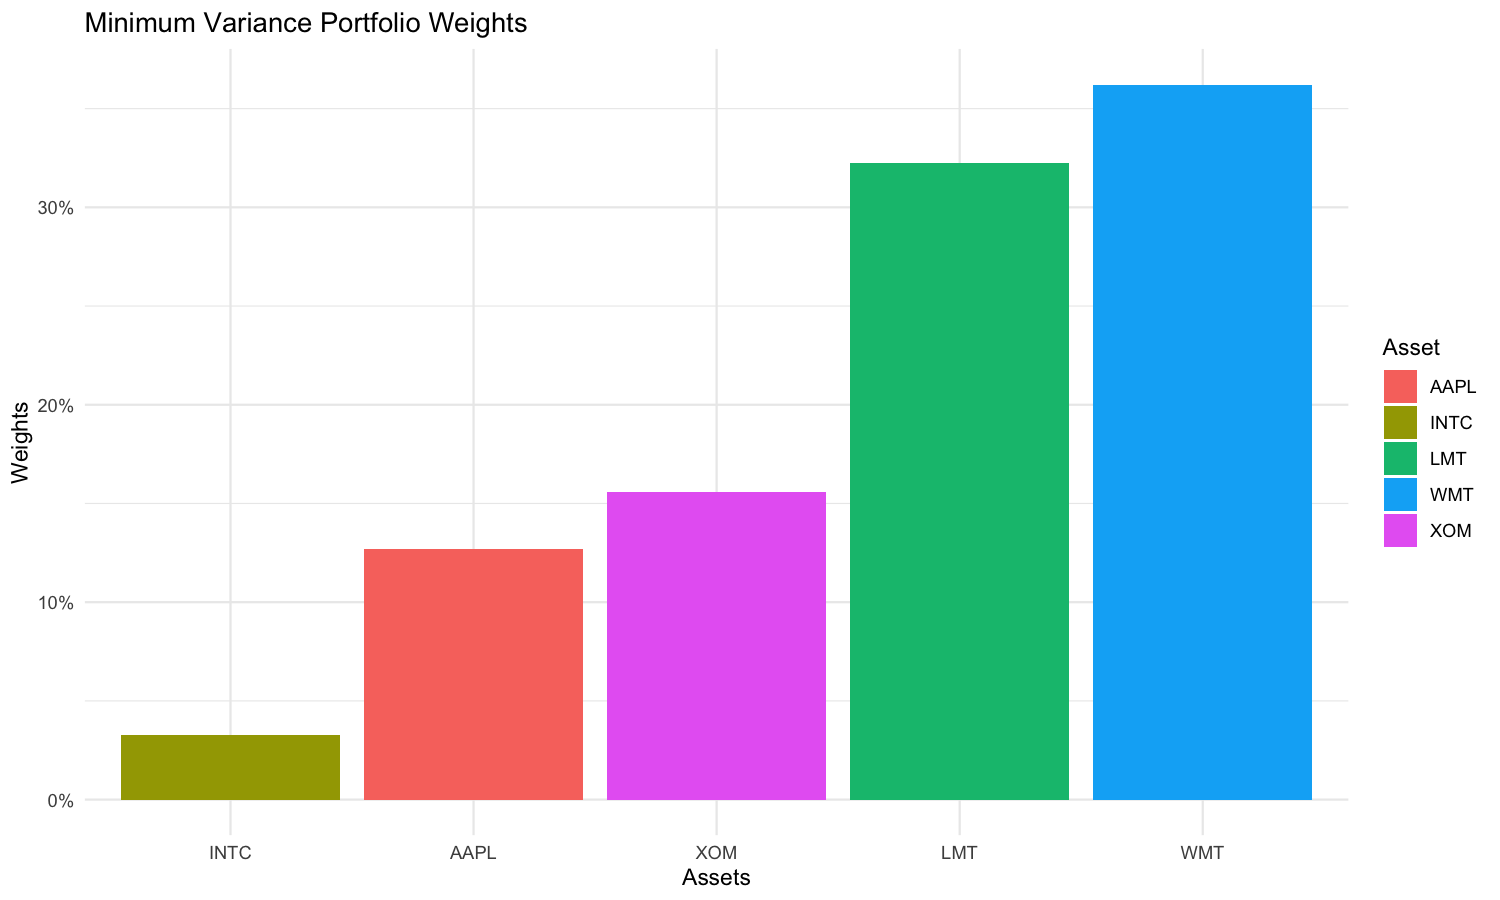

In [25]:

p <- min_var |>
  pivot_longer(cols = all_of(tick), names_to = "Asset", values_to = "Weights") |>
  mutate(Asset = as.factor(Asset)) |>
  ggplot(aes(x = fct_reorder(Asset,Weights), y = Weights, fill = Asset)) +
  geom_bar(stat = 'identity') +
  theme_minimal() +
  labs(x = 'Assets', y = 'Weights', title = "Minimum Variance Portfolio Weights") +
  scale_y_continuous(labels = scales::percent)

p

## 🎯 El Portfolio de Tangencia

In [26]:
max_sr <- portfolio_values[which.max(portfolio_values$SharpeRatio),]
max_sr

,AAPL,WMT,INTC,XOM,LMT,Return,Risk,SharpeRatio
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3853,0.1018972,0.4346019,0.001760641,0.4262955,0.03544478,0.2293023,0.1691488,1.09473


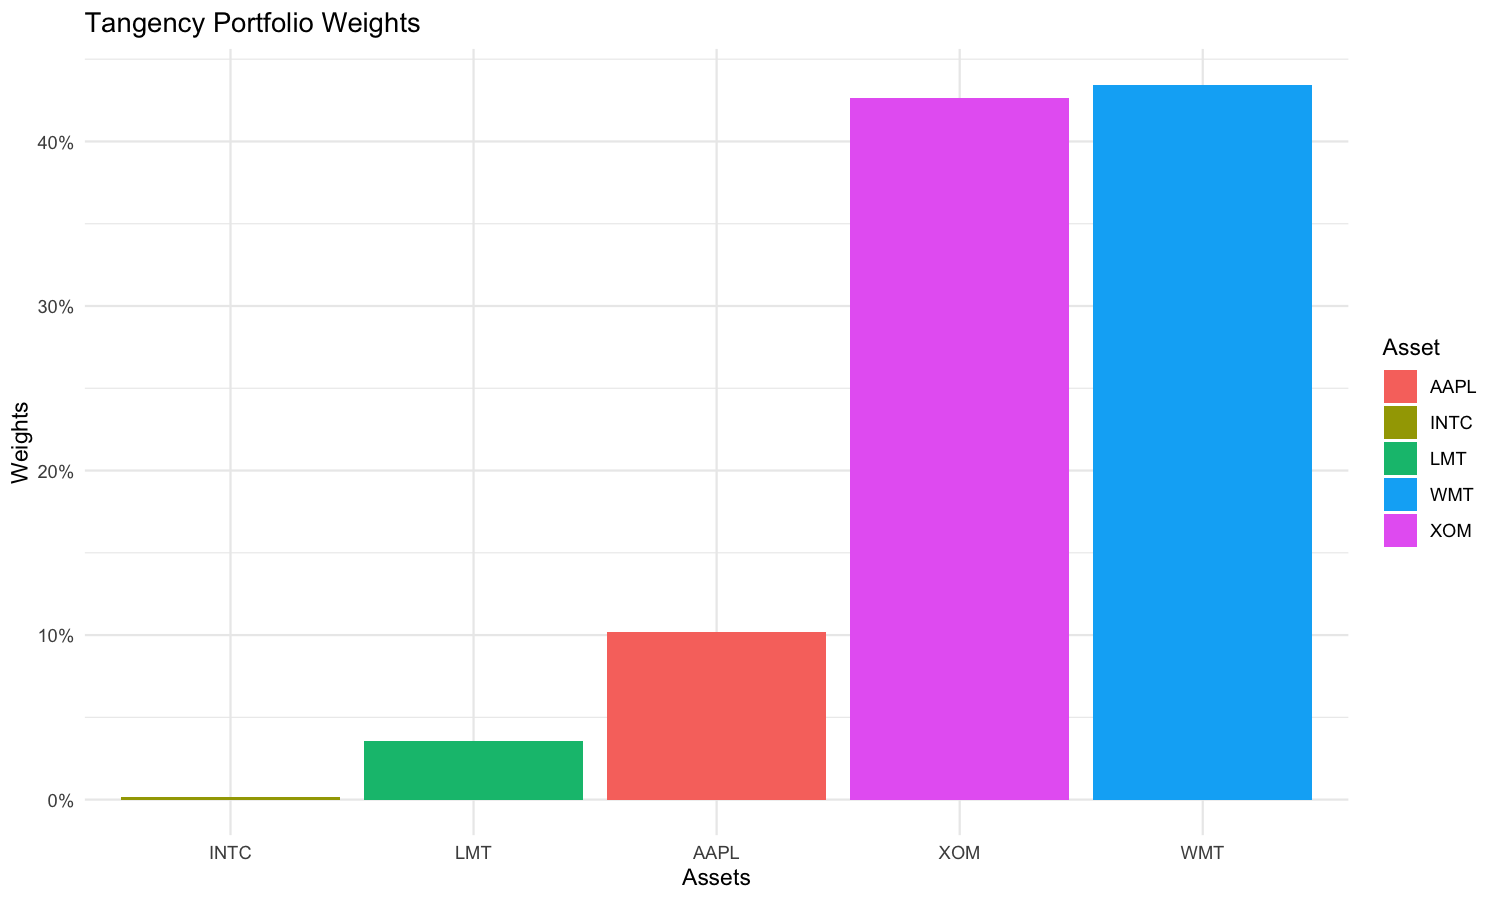

In [27]:
p <- max_sr |>
  pivot_longer(cols = all_of(tick), names_to = "Asset", values_to = "Weights") |>
  mutate(Asset = as.factor(Asset)) |>
  ggplot(aes(x = fct_reorder(Asset,Weights), y = Weights, fill = Asset)) +
  geom_bar(stat = 'identity') +
  theme_minimal() +
  labs(x = 'Assets', y = 'Weights', title = "Tangency Portfolio Weights") +
  scale_y_continuous(labels = scales::percent)
p

## 📉 La Frontera Eficiente

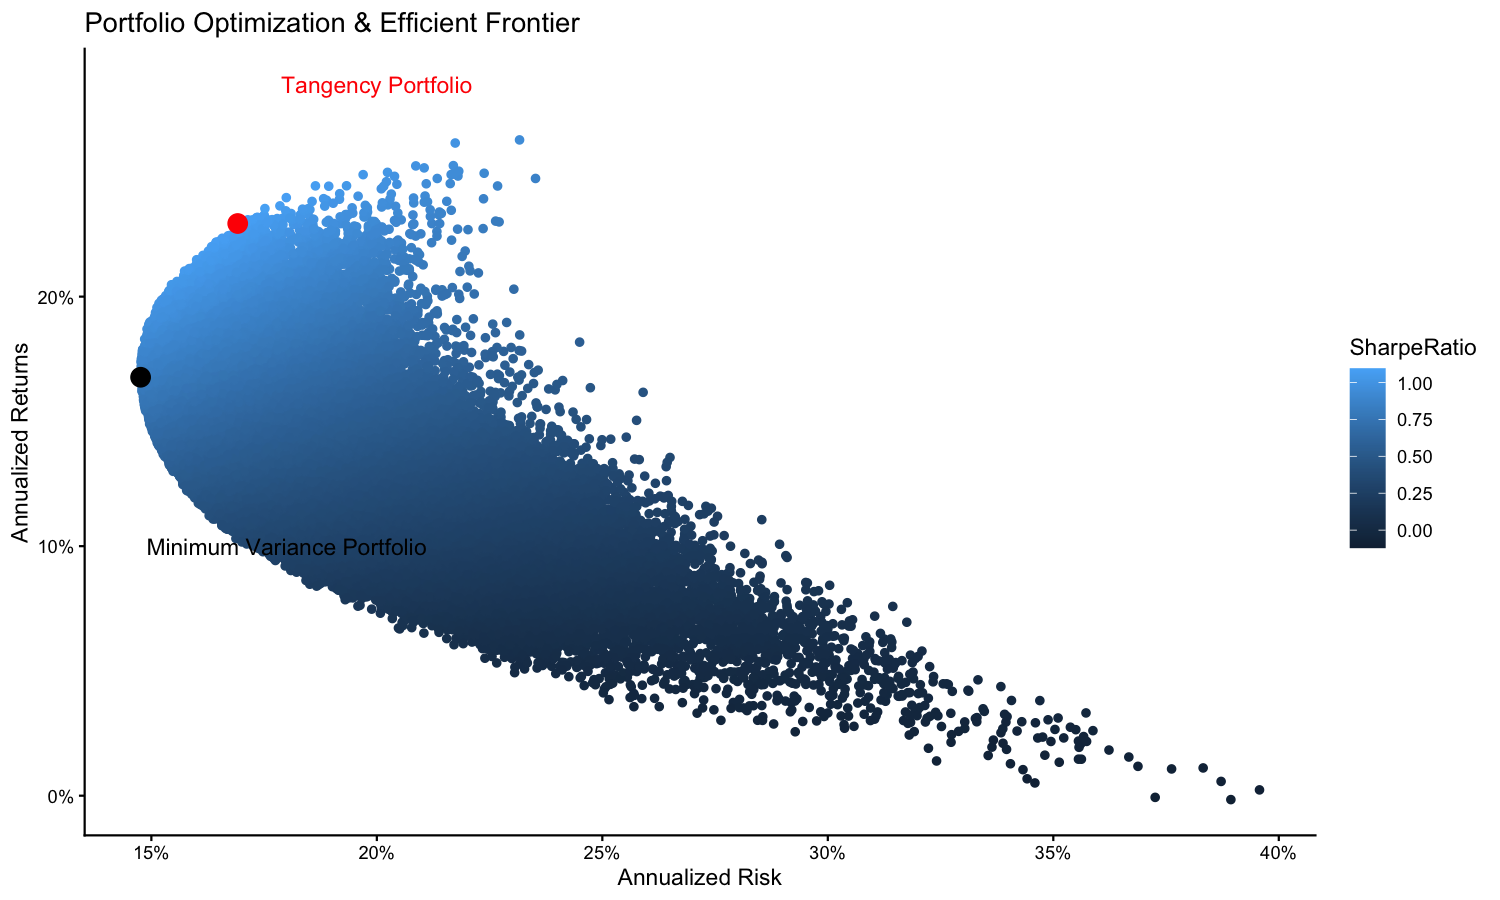

In [28]:

p <- portfolio_values |>
  ggplot(aes(x = Risk, y = Return, color = SharpeRatio)) +
  geom_point() +
  theme_classic() +
  scale_y_continuous(labels = scales::percent) +
  scale_x_continuous(labels = scales::percent) +
  labs(x = 'Annualized Risk',
       y = 'Annualized Returns',
       title = "Portfolio Optimization & Efficient Frontier") +
  geom_point(aes(x = Risk,
                 y = Return), data = min_var, color = 'black',size=4) +
  geom_point(aes(x = Risk,
                 y = Return), data = max_sr, color = 'red',size=4) +
  annotate('text', x = 0.20, y = 0.285, label = "Tangency Portfolio",
           color = 'red') +
  annotate('text', x = 0.18, y = 0.10, label = "Minimum Variance Portfolio",
           color = 'black')
p

Y si lo queremos grabar:

In [30]:
#ggsave(p, file="Frontera_Ef.png", device=cairo_ps,width=10, height=5)